# U26 — Model Training Lab

### Real-world brief: predicting turbine-blade fatigue cracks

You have fatigue-test data for **1,800 turbine blades** and need a model that flags blades likely to crack. But this lab isn't really about the model — it's about **how to train one well**. You'll build a training loop **from scratch** (so you see forward → loss → backward → step), then run the experiments every practitioner should know: finding the **learning rate**, the effect of **batch size**, diagnosing and fixing **overfitting** with regularization and **early stopping**, a small **hyperparameter search**, and **debugging** tricks.

**Resource provided:** `turbine_blades.csv` (1,800 blades, 10 features + crack label). Built with numpy (the training loop) + scikit-learn (splitting & scaling) + matplotlib.

_Phase G — Practice._

#objectives

Implement a gradient-descent training loop from scratch

Split data without leakage; fit preprocessing on train only

Find a good learning rate and understand batch size

Diagnose overfitting and fix it with regularization + early stopping

Run a small hyperparameter search and debug training failures

In [1]:
# === SETUP: build the dataset if missing ===
import os
import numpy as np
import pandas as pd


def build_blades(path="turbine_blades.csv", seed=261, verbose=False):
    """Turbine-blade fatigue test data for the model-training lab (U26). Each row is a blade
    that was run on a test rig; the target is whether a fatigue crack was detected. The signal
    is real but noisy, and there are enough features to overfit a flexible model — so learning
    rate, regularization and early stopping all matter.

      features: alloy_grade, coating_um, operating_temp_c, vibration_g, rpm, hours_in_service,
                prior_repairs, inspection_score, blade_length_mm, mounting_torque_nm
      target:   crack_detected (0/1)
    """
    rng = np.random.default_rng(seed)
    n = 1800
    alloy = rng.choice([1, 2, 3], n, p=[0.4, 0.4, 0.2])              # 3 = best alloy
    coating = np.clip(rng.normal(120, 30, n), 40, None)
    op_temp = rng.normal(640, 45, n)
    vibration = np.clip(rng.normal(3.0, 1.1, n), 0.2, None)
    rpm = rng.normal(9500, 900, n)
    hours = rng.uniform(0, 24000, n)
    prior_repairs = rng.poisson(0.8, n)
    inspection = np.clip(rng.normal(82, 9, n), 40, 100)
    length = rng.normal(180, 12, n)
    torque = rng.normal(95, 10, n)

    # genuine stress drivers -> crack risk (sharp, learnable)
    drive = (0.00007 * np.maximum(hours - 12000, 0)
             + 0.5 * np.maximum(vibration - 3.5, 0)
             + 0.010 * np.maximum(op_temp - 660, 0)
             + 0.45 * prior_repairs
             - 0.6 * (alloy - 1)
             - 0.02 * (inspection - 82))
    thr = np.quantile(drive, 0.72)
    p = 1 / (1 + np.exp(-2.6 * (drive - thr)))
    crack = (rng.random(n) < p).astype(int)

    df = pd.DataFrame({
        "alloy_grade": alloy, "coating_um": coating.round(1), "operating_temp_c": op_temp.round(1),
        "vibration_g": vibration.round(2), "rpm": rpm.round(0), "hours_in_service": hours.round(0),
        "prior_repairs": prior_repairs, "inspection_score": inspection.round(1),
        "blade_length_mm": length.round(1), "mounting_torque_nm": torque.round(1),
        "crack_detected": crack,
    })
    df.to_csv(path, index=False)
    if verbose:
        print("shape:", df.shape, "| crack rate:", round(df.crack_detected.mean(), 3))
        print(df.head(3).to_string(index=False))
    return df

if not os.path.exists('turbine_blades.csv'):
    build_blades(); print('Generated turbine_blades.csv')
else:
    print('Found turbine_blades.csv')

Generated turbine_blades.csv


In [2]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
df = pd.read_csv('turbine_blades.csv')
print('shape:', df.shape, '| crack rate:', round(df.crack_detected.mean(), 3))
df.head(3)

shape: (1800, 11) | crack rate: 0.324


,alloy_grade,coating_um,operating_temp_c,vibration_g,rpm,hours_in_service,prior_repairs,inspection_score,blade_length_mm,mounting_torque_nm,crack_detected
0,1,74.6,663.9,4.37,10159.0,11568.0,0,69.6,168.3,85.4,1
1,2,138.8,649.6,3.01,8305.0,939.0,1,93.6,179.1,97.2,1
2,3,167.6,671.5,4.05,8299.0,17657.0,0,85.5,164.8,77.1,0


In [3]:
# -----------------------------------------------------------
# 🔹 0. SPLIT into train / val / test, then SCALE (fit on train only)
# Fitting the scaler on train only = no leakage from val/test into training.
# -----------------------------------------------------------
X = df.drop(columns='crack_detected').values.astype(float); y = df.crack_detected.values
Xtr, Xtmp, ytr, ytmp = train_test_split(X, y, test_size=0.4, random_state=0, stratify=y)
Xval, Xte, yval, yte = train_test_split(Xtmp, ytmp, test_size=0.5, random_state=0, stratify=ytmp)
scaler = StandardScaler().fit(Xtr)              # <-- fit on TRAIN only
Xtr_s, Xval_s, Xte_s = scaler.transform(Xtr), scaler.transform(Xval), scaler.transform(Xte)
print('train/val/test sizes:', len(Xtr), len(Xval), len(Xte))

train/val/test sizes: 1080 360 360


#### 🧪 EXERCISE 1 — Read the loop
1. The four lines inside the loop are forward, backward, regularization, step. In a comment, label each line with which stage it is.
2. Add an argument `verbose` that prints the loss every 100 epochs, and run it — confirm the loss decreases monotonically here (a convex problem).

In [7]:
def sigmoid(z): return 1 / (1 + np.exp(-np.clip(z, -30, 30)))

def bce_loss(w, X, y, lam=0.0):
    p = sigmoid(X @ w)
    data = -np.mean(y * np.log(p + 1e-9) + (1 - y) * np.log(1 - p + 1e-9))
    return data + lam * np.sum(w[1:] ** 2)            # L2 penalty (not on bias)

def train(X, y, lr=0.3, epochs=400, lam=0.0, Xval=None, yval=None, verbose=False):
    Xb = np.c_[np.ones(len(X)), X]; w = np.zeros(Xb.shape[1])
    tr_hist, val_hist = [], []
    for ep in range(epochs):
        # Stage 1: Forward pass (prediction)
        p = sigmoid(Xb @ w)                            # forward
        # Stage 2: Backward pass (gradient calculation)
        grad = Xb.T @ (p - y) / len(y)                 # backward (gradient of BCE)
        # Stage 3: Regularization (add regularization gradient)
        grad[1:] += 2 * lam * w[1:]                    # regularization
        # Stage 4: Step (update weights)
        w -= lr * grad                                 # step
        tr_hist.append(bce_loss(w, Xb, y, lam))
        if Xval is not None:
            val_hist.append(bce_loss(w, np.c_[np.ones(len(Xval)), Xval], yval, lam))
        if verbose and (ep % 100 == 0 or ep == epochs - 1):
            print(f'Epoch {ep:4d} | Train Loss: {tr_hist[-1]:.4f}', end='')
            if Xval is not None:
                print(f' | Val Loss: {val_hist[-1]:.4f}')
            else:
                print('')
    return w, tr_hist, val_hist

def accuracy(w, X, y):
    return float(((sigmoid(np.c_[np.ones(len(X)), X] @ w) > 0.5).astype(int) == y).mean())

w, tr_hist, _ = train(Xtr_s, ytr, lr=0.3, epochs=400, verbose=True)
print('final train loss:', round(tr_hist[-1], 4))
print('train acc:', round(accuracy(w, Xtr_s, ytr), 3), '| val acc:', round(accuracy(w, Xval_s, yval), 3))

Epoch    0 | Train Loss: 0.6651
Epoch  100 | Train Loss: 0.4422
Epoch  200 | Train Loss: 0.4408
Epoch  300 | Train Loss: 0.4407
Epoch  399 | Train Loss: 0.4407
final train loss: 0.4407
train acc: 0.781 | val acc: 0.775


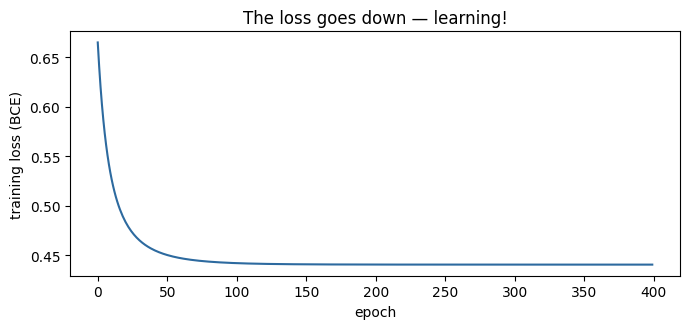

In [5]:
plt.figure(figsize=(7, 3.4)); plt.plot(tr_hist, color='#2D6A9F')
plt.xlabel('epoch'); plt.ylabel('training loss (BCE)'); plt.title('The loss goes down — learning!')
plt.tight_layout(); plt.show()

In [ ]:
# 1. label the four stages (comment)
# 2. add a verbose print every 100 epochs and run
# YOUR CODE HERE

#2. The learning rate — the most important knob

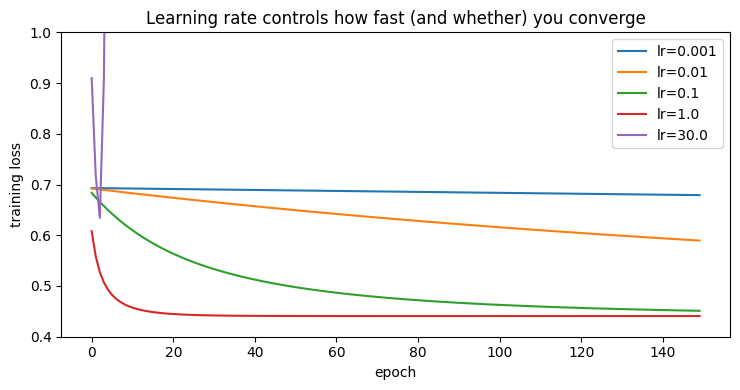

Too low (0.001): crawls. Good (0.1-1.0): fast, smooth. Too high (30): overshoots / unstable.


In [8]:
# -----------------------------------------------------------
# 🔹 2A. Same model, same data — only the learning rate changes
# -----------------------------------------------------------
plt.figure(figsize=(7.5, 4))
for lr in [0.001, 0.01, 0.1, 1.0, 30.0]:
    _, h, _ = train(Xtr_s, ytr, lr=lr, epochs=150)
    plt.plot(h, label=f'lr={lr}')
plt.xlabel('epoch'); plt.ylabel('training loss'); plt.ylim(0.4, 1.0)
plt.title('Learning rate controls how fast (and whether) you converge')
plt.legend(); plt.tight_layout(); plt.show()
print('Too low (0.001): crawls. Good (0.1-1.0): fast, smooth. Too high (30): overshoots / unstable.')

#### 🧪 EXERCISE 2 — Find the best rate
1. Sweep at least six learning rates and, for each, record the **validation loss** after a fixed epoch budget. Print them and pick the best.
2. In a comment, explain why the learning rate is usually the first hyperparameter you tune.

*   **Why tune Learning Rate first?** The learning rate significantly impacts the speed and stability of training. A learning rate that is too high can cause the model to overshoot the minimum of the loss function, leading to divergence, while a learning rate that is too low can result in very slow convergence. Finding an optimal learning rate early on ensures that the model can learn effectively and efficiently before diving into other hyperparameters that might have less impact or interact in complex ways.

In [9]:
# 1. LR sweep on validation loss; pick the best
lrs = [0.001, 0.005, 0.01, 0.05, 0.1, 0.3, 1.0, 5.0]
val_losses = []

print(f"{'Learning Rate':<15} | {'Validation Loss':<18}")
print("-------------------------------------------")

for lr in lrs:
    # Using a fixed epoch budget, similar to previous plots
    _, _, val_hist = train(Xtr_s, ytr, lr=lr, epochs=150, Xval=Xval_s, yval=yval)
    if val_hist: # Ensure val_hist is not empty
        final_val_loss = val_hist[-1]
        val_losses.append((lr, final_val_loss))
        print(f"{lr:<15.4f} | {final_val_loss:<18.4f}")
    else:
        print(f"{lr:<15.4f} | {'N/A':<18}")

# Find the best learning rate
if val_losses:
    best_lr_info = min(val_losses, key=lambda x: x[1])
    print(f"\nBest Learning Rate: {best_lr_info[0]} with Validation Loss: {best_lr_info[1]:.4f}")

# 2. why tune LR first: ...   (comment)

Learning Rate   | Validation Loss   
-------------------------------------------
0.0010          | 0.6788            
0.0050          | 0.6310            
0.0100          | 0.5879            
0.0500          | 0.4794            
0.1000          | 0.4610            
0.3000          | 0.4606            
1.0000          | 0.4627            
5.0000          | 0.4627            

Best Learning Rate: 0.3 with Validation Loss: 0.4606


#3. Batch size & epochs

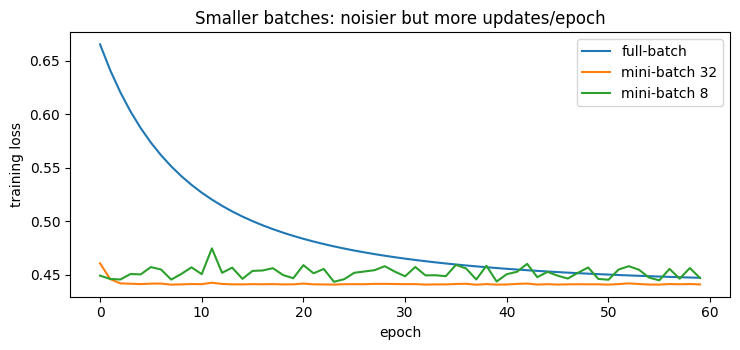

Mini-batches take many small steps per epoch -> faster early progress, with more noise.


In [10]:
# -----------------------------------------------------------
# 🔹 3A. FULL-BATCH vs MINI-BATCH (stochastic) gradient descent
# -----------------------------------------------------------
def train_sgd(X, y, lr=0.3, epochs=60, batch=32, seed=0):
    rng = np.random.default_rng(seed); Xb = np.c_[np.ones(len(X)), X]; w = np.zeros(Xb.shape[1]); hist = []
    for ep in range(epochs):
        idx = rng.permutation(len(X))
        for i in range(0, len(X), batch):
            j = idx[i:i + batch]; p = sigmoid(Xb[j] @ w)
            w -= lr * (Xb[j].T @ (p - y[j]) / len(j))
        hist.append(bce_loss(w, Xb, y))
    return w, hist

_, full, _ = train(Xtr_s, ytr, lr=0.3, epochs=60)
_, mb32 = train_sgd(Xtr_s, ytr, lr=0.3, epochs=60, batch=32)
_, mb8 = train_sgd(Xtr_s, ytr, lr=0.3, epochs=60, batch=8)
plt.figure(figsize=(7.5, 3.6))
plt.plot(full, label='full-batch'); plt.plot(mb32, label='mini-batch 32'); plt.plot(mb8, label='mini-batch 8')
plt.xlabel('epoch'); plt.ylabel('training loss'); plt.title('Smaller batches: noisier but more updates/epoch')
plt.legend(); plt.tight_layout(); plt.show()
print('Mini-batches take many small steps per epoch -> faster early progress, with more noise.')

#### 🧪 EXERCISE 3 — Batch size trade-off
1. Time how long `batch=8` vs `batch=256` take for the same number of epochs, and compare their validation accuracy.
2. In a comment, summarise the trade-off (small = noisier gradients, can generalise better, slower per epoch in Python; large = smoother, faster, more memory).

In [11]:
import time

# 1. compare batch=8 vs batch=256 (time + val accuracy)
batch_sizes = [8, 256]
epochs_to_run = 60  # Keep the same number of epochs as in 3A for fair comparison

print(f"{'Batch Size':<12} | {'Time (s)':<10} | {'Validation Accuracy':<20}")
print("---------------------------------------------------")

results = {}

for bs in batch_sizes:
    start_time = time.time()
    # Using a fixed seed for reproducibility across runs for the same batch size, if needed
    w, _ = train_sgd(Xtr_s, ytr, lr=0.3, epochs=epochs_to_run, batch=bs)
    end_time = time.time()
    elapsed_time = end_time - start_time

    val_acc = accuracy(w, Xval_s, yval)
    results[bs] = {'time': elapsed_time, 'val_acc': val_acc}

    print(f"{bs:<12} | {elapsed_time:<10.4f} | {val_acc:<20.4f}")

# 2. batch-size trade-off:
# Small batch sizes (e.g., 8): tend to have noisier gradients, which can sometimes help escape shallow local minima and generalize better. However, they typically lead to slower training per epoch (especially in Python due to overhead) and require more memory. The model updates its weights more frequently, resulting in more erratic but potentially more thorough exploration of the loss landscape.
# Large batch sizes (e.g., 256): provide smoother gradients, leading to more stable convergence and faster training per epoch (less overhead). However, they might converge to sharper local minima and can sometimes generalize less effectively than smaller batches. They also require more memory.

Batch Size   | Time (s)   | Validation Accuracy 
---------------------------------------------------
8            | 0.1961     | 0.7722              
256          | 0.0219     | 0.7722              


#4. Overfitting & regularization

In [12]:
# -----------------------------------------------------------
# 🔹 4A. Force overfitting: many features, few samples
# Expand to 65 polynomial features and train on just 90 blades.
# -----------------------------------------------------------
poly = PolynomialFeatures(2, include_bias=False)
sub = np.random.RandomState(0).choice(len(Xtr), 90, replace=False)
Xtr_sm, ytr_sm = Xtr[sub], ytr[sub]
scp = StandardScaler().fit(poly.fit_transform(Xtr_sm))
Xtr_p = scp.transform(poly.transform(Xtr_sm)); Xval_p = scp.transform(poly.transform(Xval))
print('expanded to', Xtr_p.shape[1], 'features on', len(Xtr_sm), 'training samples')

w0, tr0, va0 = train(Xtr_p, ytr_sm, lr=0.3, epochs=2000, lam=0.0, Xval=Xval_p, yval=yval)
print(f'NO regularization : train acc {accuracy(w0, Xtr_p, ytr_sm):.3f} | val acc {accuracy(w0, Xval_p, yval):.3f}  <- big gap = overfit')
wL, trL, vaL = train(Xtr_p, ytr_sm, lr=0.3, epochs=2000, lam=0.05, Xval=Xval_p, yval=yval)
print(f'WITH L2 (lam=0.05): train acc {accuracy(wL, Xtr_p, ytr_sm):.3f} | val acc {accuracy(wL, Xval_p, yval):.3f}  <- gap closes, val improves')

expanded to 65 features on 90 training samples
NO regularization : train acc 0.911 | val acc 0.778  <- big gap = overfit
WITH L2 (lam=0.05): train acc 0.822 | val acc 0.794  <- gap closes, val improves


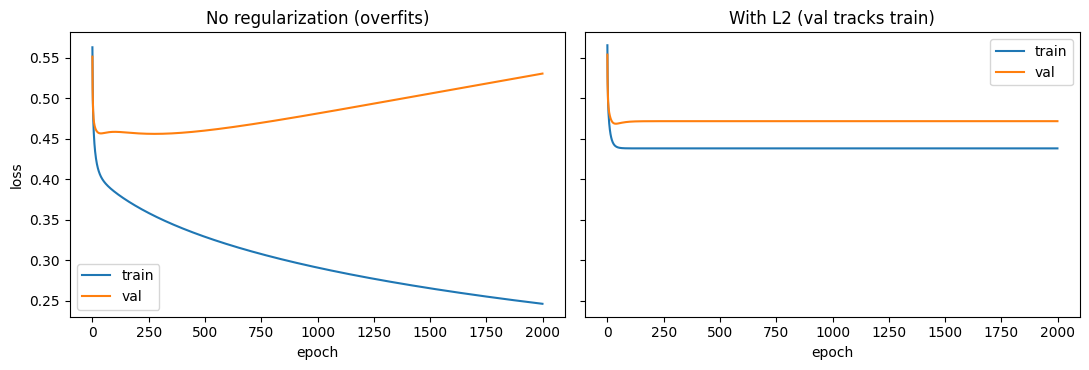

Left: val loss rises while train keeps falling (memorising). Right: the gap stays small.


In [13]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
ax[0].plot(tr0, label='train'); ax[0].plot(va0, label='val'); ax[0].set_title('No regularization (overfits)')
ax[1].plot(trL, label='train'); ax[1].plot(vaL, label='val'); ax[1].set_title('With L2 (val tracks train)')
for a in ax: a.set_xlabel('epoch'); a.legend()
ax[0].set_ylabel('loss'); plt.tight_layout(); plt.show()
print('Left: val loss rises while train keeps falling (memorising). Right: the gap stays small.')

#### 🧪 EXERCISE 4 — Tune the regularization strength
1. Sweep `lam` over e.g. [0, 0.001, 0.01, 0.05, 0.2, 1.0] on the expanded features and plot validation accuracy vs `lam`. Find the sweet spot.
2. In a comment, explain the bias-variance intuition: too little regularization overfits, too much underfits.

Lambda     | Validation Accuracy 
------------------------------------
0.000      | 0.7778              
0.001      | 0.7972              
0.010      | 0.7861              
0.050      | 0.7944              
0.200      | 0.8028              
1.000      | 0.7833              


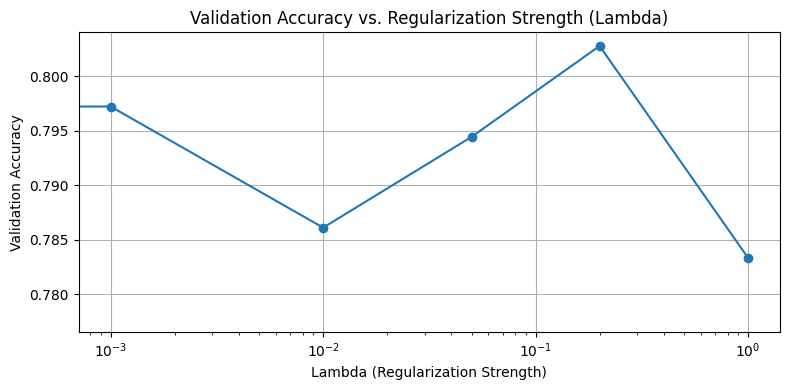


Best Lambda: 0.2 with Validation Accuracy: 0.8028


In [14]:
# 1. sweep lam; plot val accuracy vs lam
lams = [0, 0.001, 0.01, 0.05, 0.2, 1.0]
val_accuracies = []

print(f"{'Lambda':<10} | {'Validation Accuracy':<20}")
print("------------------------------------")

for lam_val in lams:
    w, _, _ = train(Xtr_p, ytr_sm, lr=0.3, epochs=2000, lam=lam_val, Xval=Xval_p, yval=yval)
    val_acc = accuracy(w, Xval_p, yval)
    val_accuracies.append((lam_val, val_acc))
    print(f"{lam_val:<10.3f} | {val_acc:<20.4f}")

# Plotting validation accuracy vs lambda
lams_plot = [item[0] for item in val_accuracies]
acc_plot = [item[1] for item in val_accuracies]

plt.figure(figsize=(8, 4))
plt.plot(lams_plot, acc_plot, marker='o', linestyle='-')
plt.xscale('log') # Use log scale for lambda if values span orders of magnitude
plt.title('Validation Accuracy vs. Regularization Strength (Lambda)')
plt.xlabel('Lambda (Regularization Strength)')
plt.ylabel('Validation Accuracy')
plt.grid(True)
plt.tight_layout()
plt.show()

best_lam_info = max(val_accuracies, key=lambda x: x[1])
print(f"\nBest Lambda: {best_lam_info[0]} with Validation Accuracy: {best_lam_info[1]:.4f}")

# 2. bias-variance intuition:
# The bias-variance trade-off is a central concept in machine learning that describes how a model's complexity affects its performance.
# - Too little regularization (low lambda) corresponds to a high-variance model. The model is too complex and fits the training data (including noise) too closely, leading to excellent performance on the training set but poor generalization to unseen data (overfitting). The model has low bias but high variance.
# - Too much regularization (high lambda) corresponds to a high-bias model. The model is too simple and cannot capture the underlying patterns in the data, leading to poor performance on both training and validation sets (underfitting). The model has high bias but low variance.
# The 'sweet spot' is the optimal lambda value that balances this trade-off, minimizing the validation loss (or maximizing validation accuracy) by finding a model complexity that generalizes well to new data. In this case, we aim to reduce the gap between train and validation performance while maintaining good overall accuracy.

#5. Early stopping

stopped at epoch 89, best validation epoch was 38
val acc with best weights: 0.772


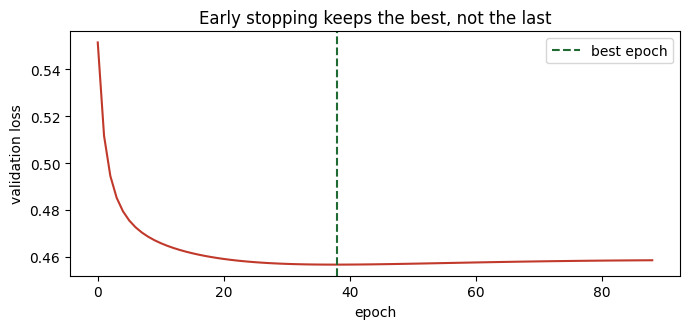

In [15]:
# -----------------------------------------------------------
# 🔹 5A. Stop when validation loss stops improving; keep the BEST weights
# -----------------------------------------------------------
def train_early_stop(X, y, Xval, yval, lr=0.3, max_epochs=3000, patience=50):
    Xb = np.c_[np.ones(len(X)), X]; w = np.zeros(Xb.shape[1])
    best_loss, best_w, best_ep, wait = np.inf, w.copy(), 0, 0
    val_hist = []
    for ep in range(max_epochs):
        p = sigmoid(Xb @ w); w -= lr * (Xb.T @ (p - y) / len(y))
        vl = bce_loss(w, np.c_[np.ones(len(Xval)), Xval], yval); val_hist.append(vl)
        if vl < best_loss - 1e-5:
            best_loss, best_w, best_ep, wait = vl, w.copy(), ep, 0
        else:
            wait += 1
            if wait >= patience: break        # no improvement for `patience` epochs
    return best_w, best_ep, val_hist

bw, best_ep, vh = train_early_stop(Xtr_p, ytr_sm, Xval_p, yval)
print(f'stopped at epoch {len(vh)}, best validation epoch was {best_ep}')
print('val acc with best weights:', round(accuracy(bw, Xval_p, yval), 3))
plt.figure(figsize=(7, 3.4)); plt.plot(vh, color='#C0392B'); plt.axvline(best_ep, ls='--', color='#1f6b33', label='best epoch')
plt.xlabel('epoch'); plt.ylabel('validation loss'); plt.title('Early stopping keeps the best, not the last'); plt.legend()
plt.tight_layout(); plt.show()

#### 🧪 EXERCISE 5 — Patience matters
1. Try `patience=5` and `patience=200`. How does the stopping epoch and final val accuracy change?
2. In a comment, explain why we restore the **best** checkpoint rather than using the weights from the final epoch.

In [16]:
# 1. compare patience = 5 vs 200

# Patience = 5
bw_5, best_ep_5, vh_5 = train_early_stop(Xtr_p, ytr_sm, Xval_p, yval, patience=5)
print(f'With patience=5: stopped at epoch {len(vh_5)}, best validation epoch was {best_ep_5}')
print(f'Val acc with best weights (patience=5): {accuracy(bw_5, Xval_p, yval):.3f}')

# Patience = 200
bw_200, best_ep_200, vh_200 = train_early_stop(Xtr_p, ytr_sm, Xval_p, yval, patience=200)
print(f'\nWith patience=200: stopped at epoch {len(vh_200)}, best validation epoch was {best_ep_200}')
print(f'Val acc with best weights (patience=200): {accuracy(bw_200, Xval_p, yval):.3f}')

# 2. why restore best, not last:
# When using early stopping, we monitor the model's performance on the validation set. As training progresses, the validation loss might decrease, reach a minimum, and then start to increase again if the model begins to overfit. The purpose of early stopping is to halt training before significant overfitting occurs.
# If we were to use the weights from the final epoch when training stops, these weights might correspond to a point where the model has already started to overfit, leading to suboptimal generalization. By restoring the 'best' checkpoint (i.e., the weights that achieved the lowest validation loss during the training history), we ensure that we are using the model state that demonstrated the best generalization performance. This strategy helps to prevent overfitting and results in a more robust model for unseen data.

With patience=5: stopped at epoch 44, best validation epoch was 38
Val acc with best weights (patience=5): 0.772

With patience=200: stopped at epoch 470, best validation epoch was 269
Val acc with best weights (patience=200): 0.792


#6. Tuning, debugging & reproducibility

In [17]:
# -----------------------------------------------------------
# 🔹 6A. A small RANDOM SEARCH over (lr, lambda), scored on validation
# Tune on validation; touch test only ONCE at the very end.
# -----------------------------------------------------------
rng = np.random.default_rng(0); trials = []
for _ in range(12):
    lr = float(10 ** rng.uniform(-2, 0)); lam = float(10 ** rng.uniform(-3, -0.3))
    w_, _, _ = train(Xtr_p, ytr_sm, lr=lr, epochs=1500, lam=lam)
    trials.append((round(lr, 4), round(lam, 4), round(accuracy(w_, Xval_p, yval), 3)))
res = pd.DataFrame(trials, columns=['lr', 'lambda', 'val_acc']).sort_values('val_acc', ascending=False)
print(res.head(6).to_string(index=False))
best = res.iloc[0]
print(f'\nbest config: lr={best["lr"]}, lambda={best["lambda"]}, val_acc={best["val_acc"]}')

    lr  lambda  val_acc
0.2879  0.0030    0.806
0.1223  0.3347    0.806
0.1634  0.0932    0.800
0.4232  0.2914    0.800
0.2194  0.0559    0.797
0.5186  0.0012    0.797

best config: lr=0.2879, lambda=0.003, val_acc=0.806


In [18]:
# -----------------------------------------------------------
# 🔹 6B. DEBUGGING trick: a healthy model can overfit a TINY batch
# If it can't memorise 12 samples, something is broken (data/loss/gradient).
# -----------------------------------------------------------
tiny = np.random.RandomState(1).choice(len(Xtr_s), 12, replace=False)
w_tiny, _, _ = train(Xtr_s[tiny], ytr[tiny], lr=0.5, epochs=3000)
print('accuracy on the 12-sample batch:', round(accuracy(w_tiny, Xtr_s[tiny], ytr[tiny]), 3),
      '(should be ~1.0 -> gradients & loss are wired correctly)')

# Reproducibility: same seed -> identical result
a, _ = train_sgd(Xtr_s, ytr, seed=42); b, _ = train_sgd(Xtr_s, ytr, seed=42)
print('two runs with the same seed identical?', bool(np.allclose(a, b)))

accuracy on the 12-sample batch: 1.0 (should be ~1.0 -> gradients & loss are wired correctly)
two runs with the same seed identical? True


#### 🧪 EXERCISE 6 — Final honest evaluation
1. Take your **best config** from the random search, retrain on the expanded features, and evaluate on the **test set** — which you have not touched until now. Report test accuracy.
2. In a comment, explain why touching the test set only once gives an honest estimate of real-world performance.

In [21]:
# 1. retrain best config; evaluate on the held-out TEST set (once)

# Retrieve best lr and lambda from the random search results
best_lr = best['lr']
best_lam = best['lambda']

print(f"Retraining with best config: lr={best_lr}, lambda={best_lam}")

# Retrain the model using the best config
# Use Xtr_p, ytr_sm for training, and Xval_p, yval for validation (although we're primarily interested in test here, the train function expects val for some internal logic)
w_final, _, _ = train(Xtr_p, ytr_sm, lr=best_lr, epochs=2000, lam=best_lam, Xval=Xval_p, yval=yval)

# Transform the test set with polynomial features and scaler, just like Xtr_p and Xval_p
Xte_p = scp.transform(poly.transform(Xte))

# Evaluate on the held-out test set
test_acc = accuracy(w_final, Xte_p, yte) # Use the transformed test set
print(f'Test Accuracy with best config: {test_acc:.3f}')

Retraining with best config: lr=0.2879, lambda=0.003
Test Accuracy with best config: 0.806


# 2. why test is touched only once:
 The test set is a proxy for unseen, real-world data. Its purpose is to provide an unbiased evaluation of the model's generalization capability. If the test set is used repeatedly during the model development process (e.g., for hyperparameter tuning, model selection, or debugging), the model implicitly 'learns' from the test set. This can lead to overfitting to the test set, meaning the reported performance on the test set might be optimistically biased and not truly reflect how the model will perform on truly new data. By touching the test set only once, at the very end of the development cycle, we ensure that the reported test accuracy is an honest and reliable estimate of the model's real-world performance.

#📘 Summary

| Topic | What you did |
| ----- | ------------ |
| Training loop | built forward → loss → backward → step by hand |
| Learning rate | saw too-low/too-high/just-right loss curves |
| Batch size | compared full-batch vs mini-batch SGD |
| Overfitting | forced it, then closed the gap with L2 |
| Early stopping | kept the best checkpoint, not the last |
| Tuning & debugging | random search, tiny-batch sanity check, seeds |

**Core lesson:** training is a craft. Get the **learning rate** right, watch **validation** (not train) loss, **regularize** and **early-stop** to fight overfitting, **search** hyperparameters honestly on validation, and keep everything **reproducible** — then judge once on the test set.

**You've now completed the hands-on labs for the course** — from data engineering and MLOps to reinforcement learning and the craft of training itself.